# Análise: McDonald's Financial Statements (2002-2022)

Este notebook organiza os passos para carregar, limpar, explorar e analisar o conjunto de dados disponível em:
https://www.kaggle.com/datasets/mikhail1681/mcdonalds-financial-statements-2002-2022

## Objetivos
- Baixar e carregar os dados do Kaggle (ou usar arquivo local).
- Limpeza e tratamento de tipos (datas, numéricos).
- Análise exploratória (tendências ao longo do tempo, missing, correlações).
- Cálculo de indicadores financeiros (margens, crescimento, retornos).
- Visualizações interativas e exportação dos resultados limpos.

In [10]:
# Instala dependências (descomente se necessário)
# !pip install -q kaggle pandas numpy matplotlib seaborn plotly openpyxl

In [11]:
# Imports básicos para a análise
import os
import glob
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set(style="whitegrid")
pd.set_option('display.max_columns', 200)

## Aquisição dos dados
Instruções: faça download manual do Kaggle ou use a API `kaggle` colocando `kaggle.json` em `~/.kaggle/`. Exemplo de comando para baixar (no terminal):

kaggle datasets download -d mikhail1681/mcdonalds-financial-statements-2002-2022

In [12]:
# Tenta localizar CSV/ZIP automaticamente na pasta do repositório
root = '.'
files = glob.glob(os.path.join(root, '**', '*.csv'), recursive=True) + glob.glob(os.path.join(root, '**', '*.zip'), recursive=True)
files = [f for f in files if 'kaggle' not in f.lower()]
files[:20]

['.\\data\\McDonalds_Financial_Statements.csv',
 '.\\venv\\Lib\\site-packages\\matplotlib\\mpl-data\\sample_data\\data_x_x2_x3.csv',
 '.\\venv\\Lib\\site-packages\\matplotlib\\mpl-data\\sample_data\\msft.csv',
 '.\\venv\\Lib\\site-packages\\matplotlib\\mpl-data\\sample_data\\Stocks.csv',
 '.\\venv\\Lib\\site-packages\\numpy\\random\\tests\\data\\mt19937-testset-1.csv',
 '.\\venv\\Lib\\site-packages\\numpy\\random\\tests\\data\\mt19937-testset-2.csv',
 '.\\venv\\Lib\\site-packages\\numpy\\random\\tests\\data\\pcg64-testset-1.csv',
 '.\\venv\\Lib\\site-packages\\numpy\\random\\tests\\data\\pcg64-testset-2.csv',
 '.\\venv\\Lib\\site-packages\\numpy\\random\\tests\\data\\pcg64dxsm-testset-1.csv',
 '.\\venv\\Lib\\site-packages\\numpy\\random\\tests\\data\\pcg64dxsm-testset-2.csv',
 '.\\venv\\Lib\\site-packages\\numpy\\random\\tests\\data\\philox-testset-1.csv',
 '.\\venv\\Lib\\site-packages\\numpy\\random\\tests\\data\\philox-testset-2.csv',
 '.\\venv\\Lib\\site-packages\\numpy\\random\\tes

In [13]:
# Se encontrar ZIP com os dados, descompacta; se encontrar CSV, carrega o primeiro que fizer sentido
data_path = None
for f in files:
    if f.lower().endswith('.zip'):
        with zipfile.ZipFile(f, 'r') as z:
            z.extractall('data')
        data_path = 'data'
        break
    if f.lower().endswith('.csv'):
        data_path = f
        break

data_path

'.\\data\\McDonalds_Financial_Statements.csv'

In [14]:
# Carrega o(s) CSV(s) encontrados na pasta `data` ou o arquivo direto
candidates = []
if os.path.isdir('data'):
    candidates = glob.glob('data/**/*.csv', recursive=True)
elif data_path and data_path.lower().endswith('.csv'):
    candidates = [data_path]

if not candidates:
    print('Nenhum CSV encontrado automaticamente. Faça o download dos dados do Kaggle e coloque-os na pasta do repositório ou em ./data')
else:
    print('Arquivos CSV encontrados:', candidates)
    # Carrega o primeiro CSV por padrão
    df = pd.read_csv(candidates[0])
    print('Tamanho:', df.shape)
    display(df.head())

Arquivos CSV encontrados: ['data\\McDonalds_Financial_Statements.csv']
Tamanho: (21, 17)


,Year,Market cap ($B),Revenue ($B),Earnings ($B),P/E ratio,P/S ratio,P/B ratio,Operating Margin (%),EPS ($),Shares Outstanding ($B),Cash on Hand ($B),Dividend Yield (%),Dividend (stock split adjusted) ($),Net assets ($B),Total assets ($B),Total debt ($B),Total liabilities ($B)
0,2022,193.01,23.18,7.82,31.3,8.33,-32.2,33.76,8.42,0.73,2.58,2.15,5.66,-6.01,50.43,48.03,56.43
1,2021,200.31,23.22,9.12,26.5,8.63,-43.5,39.31,10.11,0.74,4.70,1.96,5.25,-4.61,53.60,48.64,58.20
2,2020,159.88,19.20,6.14,33.8,8.32,-20.4,31.97,6.35,0.74,3.44,2.35,5.04,-7.83,52.62,48.51,60.45
3,2019,147.47,21.28,8.01,24.8,6.93,-18.0,38.04,7.98,0.74,0.89,2.39,4.73,-8.22,47.51,46.87,55.72
4,2018,136.21,21.02,7.81,23.2,6.48,-21.8,37.17,7.65,0.76,0.86,2.36,4.19,-6.26,32.81,31.07,39.06


## Limpeza e preparação dos dados
Passos sugeridos: identificar colunas de data, converter colunas numéricas (remover `,` e `$`), tratar `NaN`, e normalizar nomes de colunas.

In [15]:
# Exemplo genérico de limpeza
def clean_numeric(col):
    return pd.to_numeric(col.astype(str).str.replace('\,', '').str.replace('\$', '').str.replace('(', '-').str.replace(')', ''), errors='coerce')

if 'df' in globals():
    # mostra info inicial
    display(df.info())
    # tenta detectar coluna de data
    date_cols = [c for c in df.columns if 'date' in c.lower() or 'year' in c.lower()]
    date_cols
    if date_cols:
        for c in date_cols:
            df[c] = pd.to_datetime(df[c], errors='coerce')
    # tenta converter colunas numéricas comuns
    for c in df.columns:
        if df[c].dtype == object:
            sample = df[c].dropna().astype(str).head(5).tolist()
            if any(('$' in s or ',' in s or '(' in s or ')' in s) for s in sample):
                df[c] = clean_numeric(df[c])
    display(df.head())
else:
    print('Nenhum dataframe carregado para limpar.')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 17 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Year                                 21 non-null     int64  
 1   Market cap ($B)                      21 non-null     float64
 2   Revenue ($B)                         21 non-null     float64
 3   Earnings ($B)                        21 non-null     float64
 4   P/E ratio                            21 non-null     float64
 5   P/S ratio                            21 non-null     float64
 6   P/B ratio                            21 non-null     float64
 7   Operating Margin (%)                 21 non-null     float64
 8   EPS ($)                              21 non-null     float64
 9   Shares Outstanding ($B)              21 non-null     float64
 10  Cash on Hand ($B)                    21 non-null     float64
 11  Dividend Yield (%)                

None

,Year,Market cap ($B),Revenue ($B),Earnings ($B),P/E ratio,P/S ratio,P/B ratio,Operating Margin (%),EPS ($),Shares Outstanding ($B),Cash on Hand ($B),Dividend Yield (%),Dividend (stock split adjusted) ($),Net assets ($B),Total assets ($B),Total debt ($B),Total liabilities ($B)
0,1970-01-01 00:00:00.000002022,193.01,23.18,7.82,31.3,8.33,-32.2,33.76,8.42,0.73,2.58,2.15,5.66,-6.01,50.43,48.03,56.43
1,1970-01-01 00:00:00.000002021,200.31,23.22,9.12,26.5,8.63,-43.5,39.31,10.11,0.74,4.70,1.96,5.25,-4.61,53.60,48.64,58.20
2,1970-01-01 00:00:00.000002020,159.88,19.20,6.14,33.8,8.32,-20.4,31.97,6.35,0.74,3.44,2.35,5.04,-7.83,52.62,48.51,60.45
3,1970-01-01 00:00:00.000002019,147.47,21.28,8.01,24.8,6.93,-18.0,38.04,7.98,0.74,0.89,2.39,4.73,-8.22,47.51,46.87,55.72
4,1970-01-01 00:00:00.000002018,136.21,21.02,7.81,23.2,6.48,-21.8,37.17,7.65,0.76,0.86,2.36,4.19,-6.26,32.81,31.07,39.06


## Análise exploratória (EDA)
- Tendências ao longo do tempo (receita, lucro líquido, ativos etc.).
- Missing data por coluna e por ano.
- Correlações entre principais indicadores.

,year,Market cap ($B),Revenue ($B),Earnings ($B),P/E ratio,P/S ratio,P/B ratio,Operating Margin (%),EPS ($),Shares Outstanding ($B),Cash on Hand ($B),Dividend Yield (%),Dividend (stock split adjusted) ($),Net assets ($B),Total assets ($B),Total debt ($B),Total liabilities ($B)
0,1970,2033.31,476.83,130.51,454.9,88.93,-149.1,564.67,101.91,20.89,50.14,52.23,57.84,151.56,735.34,447.01,583.67


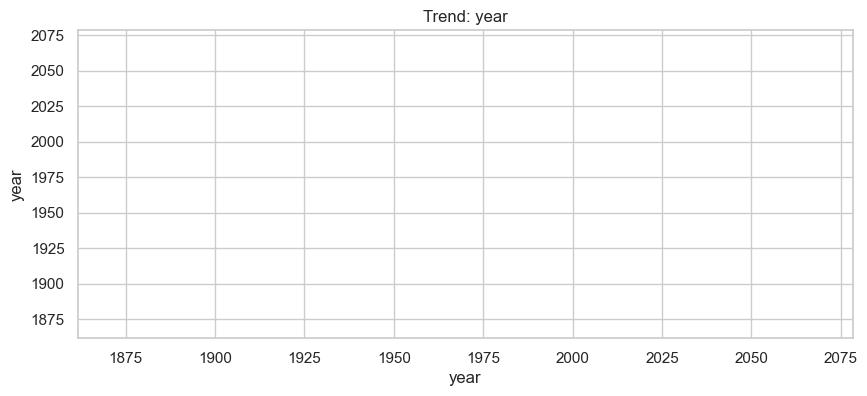

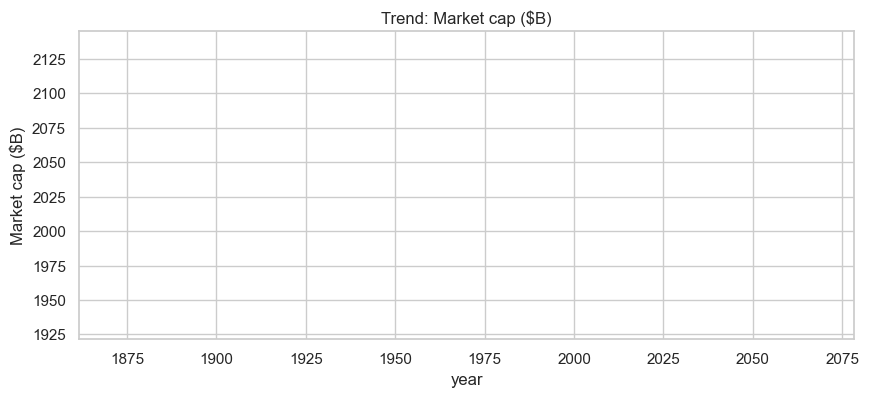

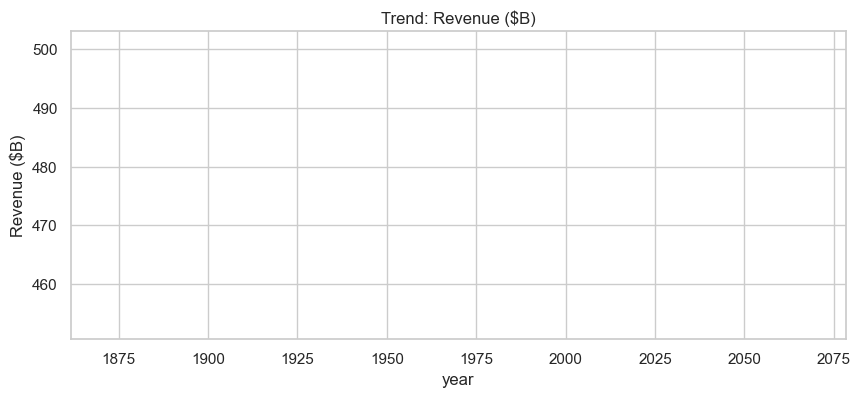

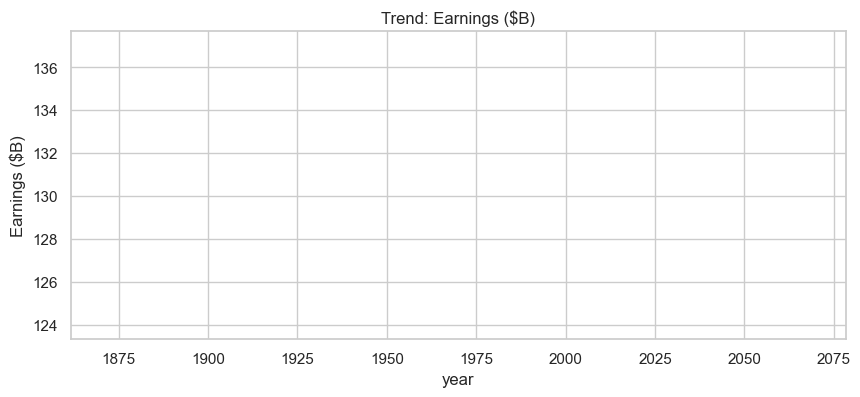

In [16]:
if 'df' in globals():
    # Exemplo: agrupar por ano se existir coluna de data
    if any(np.issubdtype(dt, np.datetime64) for dt in df.dtypes):
        # tenta identificar a primeira coluna datetime
        date_col = [c for c in df.columns if np.issubdtype(df[c].dtype, np.datetime64)][0]
        df['year'] = df[date_col].dt.year
        yearly = df.groupby('year').sum(numeric_only=True).reset_index()
        display(yearly.head())
        # plot exemplo
        num_cols = yearly.select_dtypes(include=[np.number]).columns.tolist()[:4]
        for col in num_cols:
            plt.figure(figsize=(10,4))
            sns.lineplot(data=yearly, x='year', y=col)
            plt.title(f'Trend: {col}')
            plt.show()
    else:
        print('Nenhuma coluna de data detectada para análise por ano.')
else:
    print('Carregue o dataframe antes de executar a EDA.')

## Indicadores financeiros sugeridos
- Margem bruta, margem líquida, crescimento ano-a-ano, crescimento composto (CAGR).
- Retornos sobre ativos e patrimônio (se existirem as colunas correspondentes).
- Análise de volatilidade e sazonalidade.

In [17]:
# Exemplo de cálculo de margens se existirem colunas chamadas 'Revenue' e 'Net Income'
if 'df' in globals():
    for col in ['Revenue', 'Net Income', 'Total Assets', 'Total Equity']:
        if col not in df.columns:
            print(f'Coluna {col} não encontrada; ajuste os nomes conforme o dataset.')
    if 'Revenue' in df.columns and 'Net Income' in df.columns:
        df['net_margin'] = df['Net Income'] / df['Revenue']
        display(df[['Revenue','Net Income','net_margin']].head())
else:
    print('Carregue e normalize o dataframe antes de calcular indicadores.')

Coluna Revenue não encontrada; ajuste os nomes conforme o dataset.
Coluna Net Income não encontrada; ajuste os nomes conforme o dataset.
Coluna Total Assets não encontrada; ajuste os nomes conforme o dataset.
Coluna Total Equity não encontrada; ajuste os nomes conforme o dataset.


## Salvando resultados
- Salve o conjunto limpo em `data/cleaned_mcdo.csv` e exporte gráficos conforme necessário.

In [18]:
if 'df' in globals():
    os.makedirs('data', exist_ok=True)
    df.to_csv('data/cleaned_mcdo.csv', index=False)
    print('Dados limpos salvos em data/cleaned_mcdo.csv')
else:
    print('Nada para salvar. Carregue e limpe o dataframe primeiro.')

Dados limpos salvos em data/cleaned_mcdo.csv


---
Próximos passos sugeridos:
- Ajustar nomes de colunas para os nomes reais do CSV baixado.
- Implementar cálculos detalhados de indicadores e análises por segmento (se houver).
- Criar dashboards interativos com Plotly Dash ou Streamlit para apresentação.